## Create a TensorRT enginee on an existing resnet50 onnx 

```
ONNX model --> TensorRT Engine (.plan) --> infrence script --> Nsight System profiling --> Latency/GPU timeline analysis
```
# set clock 
```
!sudo nvpmodel -m 0
!sudo jetson_clocks
```

### Download existing onnx model.
Note : Some times wget may corrupt the file, in that case download directly

In [3]:
#!wget https://github.com/onnx/models/blob/main/validated/vision/classification/resnet/model/resnet50-v1-7.onnx

--2026-02-15 22:39:56--  https://github.com/onnx/models/blob/main/validated/vision/classification/resnet/model/resnet50-v1-7.onnx
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘resnet50-v1-7.onnx’

resnet50-v1-7.onnx      [ <=>                ] 192.63K  --.-KB/s    in 0.03s   

2026-02-15 22:39:57 (6.96 MB/s) - ‘resnet50-v1-7.onnx’ saved [197256]



### Verify ONNX 

In [12]:
#verify Onnx runtime

import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("./models/resnet50-v1-7.onnx")
input_name = session.get_inputs()[0]
dummy = np.random.randn(1,3,224,224).astype(np.float32)

# pirnt the name and hsape of all inputs
for input in session.get_inputs():
    print(f"Input Name : {input.name}")
    print(f"Input Shape: {input.shape}")


outputs = session.run(None, {'data': dummy})
print(f"Output shape {outputs[0].shape}")

Input Name : data
Input Shape: ['N', 3, 224, 224]
Output shape (1, 1000)


### Convert Onnx file to TensorRT Engine file

In [ ]:
# Base FP16 conversion
# onnx file location ./models/resnet50-v1-7.onnx

!/usr/src/tensorrt/bin/trtexec --onnx='./models/resnet50-v1-7.onnx' --saveEngine=./enginefiles/resnet50_fp16_engine_pytorch.plan --fp16 --verbose



&&&& RUNNING TensorRT.trtexec [TensorRT v100300] # /usr/src/tensorrt/bin/trtexec --onnx=./models/resnet50-v1-7.onnx --saveEngine=./enginefiles/resnet50_fp16_engine_pytorch.plan --fp16 --verbose
[02/16/2026-08:42:56] [I] === Model Options ===
[02/16/2026-08:42:56] [I] Format: ONNX
[02/16/2026-08:42:56] [I] Model: ./models/resnet50-v1-7.onnx
[02/16/2026-08:42:56] [I] Output:
[02/16/2026-08:42:56] [I] === Build Options ===
[02/16/2026-08:42:56] [I] Memory Pools: workspace: default, dlaSRAM: default, dlaLocalDRAM: default, dlaGlobalDRAM: default, tacticSharedMem: default
[02/16/2026-08:42:56] [I] avgTiming: 8
[02/16/2026-08:42:56] [I] Precision: FP32+FP16
[02/16/2026-08:42:56] [I] LayerPrecisions: 
[02/16/2026-08:42:56] [I] Layer Device Types: 
[02/16/2026-08:42:56] [I] Calibration: 
[02/16/2026-08:42:56] [I] Refit: Disabled
[02/16/2026-08:42:56] [I] Strip weights: Disabled
[02/16/2026-08:42:56] [I] Version Compatible: Disabled
[02/16/2026-08:42:56] [I] ONNX Plugin InstanceNorm: Disabled
[

In [7]:
!ls /usr/src/tensorrt/bin/trtexec -h

/usr/src/tensorrt/bin/trtexec


In [ ]:
import torch
import torchvision.models as models
import onnx
model = models.resnet50(pretrained=True, progress=False)
model = model.eval()

# get onnx file
BATCH_SIZE = 32
dummy_input = torch.randn(BATCH_SIZE, 3, 224, 224)
torch.onnx.export(model, dummy_input, './models/onnxdl/resnet50_pytorch.onmx', verbose=True)


/home/ppooboni/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ppooboni/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/tmp/ipykernel_15607/575705537.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it

In [2]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
#pip install scikit-image
from skimage import io 
from skimage.transform import resize
from matplotlib import pyplot as plt
import numpy as np

url='https://images.dog.ceo/breeds/retriever-golden/n02099601_3004.jpg'
# resize 
img = resize(io.imread(url), (244, 244))
img = np.expand_dims(np.array(img, dtype=np.float32), axis=0) # expand imag to have a batch dimension
BATCH_SIZE = 32
input_batch = np.array(np.repeat(img, BATCH_SIZE, axis=0), dtype=np.float32)

input_batch.shape

(32, 244, 244, 3)

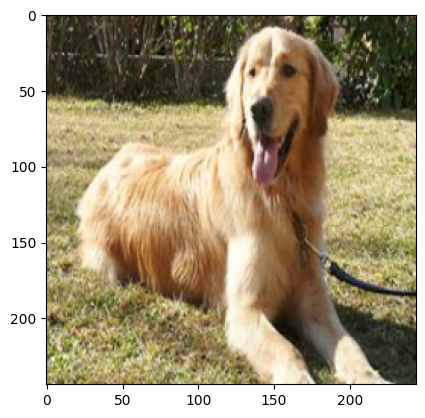

In [4]:
plt.imshow(input_batch[0].astype(np.float32))

In [9]:
# move the batch to gpu

input_batch_chw = torch.from_numpy(input_batch).transpose(1,3).transpose(2,3)
input_batch_gpu = input_batch_chw.to("cuda")

# run preduction on the batch
with torch.no_grad():
    predications = np.array(model(input_batch_gpu).cpu())
    outputs = model(input_batch_gpu)
    _, indx = torch.max(outputs, 1)

from torchvision.models import ResNet50_Weights
weights = ResNet50_Weights.DEFAULT
categories = weights.meta['categories']

print(f'Predicted Name : {categories[indx[0]]}')
predications.shape

Predicted Name : golden retriever


(32, 1000)

In [10]:
USE_FP16 = True
target_dtype = np.float16 if USE_FP16 else npfloat32
target_dtype

numpy.float16

/tmp/ipykernel_14776/2074516589.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(model, dummy_input, './models/onnxdl/resnet50_pytorch.onmx', verbose=True)


RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

In [11]:
# Check tensor rt insstallation
import tensorrt
if USE_FP16:
    !trtexec --onnx=resnet50_pytorch.onnx --saveEngine=